# Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from warnings import filterwarnings
filterwarnings("ignore")

# Data Imports

In [2]:
df = pd.read_csv("cleaned_financial_data.csv")
df["Transaction_Date"] = pd.to_datetime(df["Transaction_Date"])
df["Transaction_Day"] = df["Transaction_Date"].dt.day_name()
df.head()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status,Qty_Bin,Transaction_Day
0,T7685,2020-01-01,C257,Coffee Machine,9,945.87300,creditcard,completed,Large,Wednesday
1,T46858,2020-01-01,C3054,Coffee Machine,2,952.32684,paypal,pending,Small,Wednesday
2,T59619,2020-01-01,C4785,Smartphone,5,529.78080,creditcard,completed,Medium,Wednesday
3,T22312,2020-01-01,C687,Tablet,973,848.48645,cash,completed,Bulk,Wednesday
4,T39156,2020-01-01,C4666,Coffee Machine,1,800.94090,creditcard,failed,Small,Wednesday


In [3]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 90340 entries, 0 to 90339
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction_ID      90340 non-null  str           
 1   Transaction_Date    90340 non-null  datetime64[us]
 2   Customer_ID         90340 non-null  str           
 3   Product_Name        90340 non-null  str           
 4   Quantity            90340 non-null  int64         
 5   Price               90340 non-null  float64       
 6   Payment_Method      90340 non-null  str           
 7   Transaction_Status  90340 non-null  str           
 8   Qty_Bin             90340 non-null  str           
 9   Transaction_Day     90340 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(7)
memory usage: 11.0 MB


## Transaction status

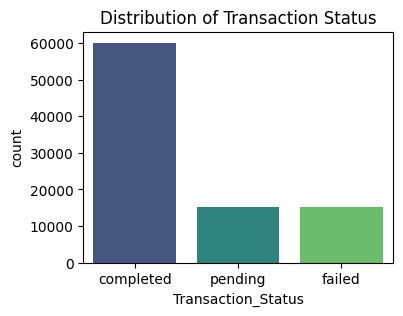

In [4]:
plt.figure(figsize=(4, 3))
sns.countplot(data=df, x='Transaction_Status', palette='viridis')
plt.title('Distribution of Transaction Status')
plt.show()

## Feature Engineering Total Price

In [5]:
df['Total_Amount'] = df['Quantity'] * df['Price']

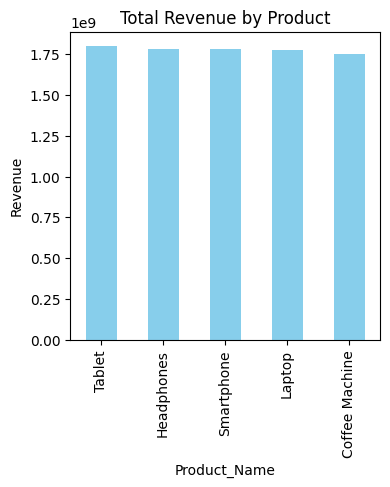

In [6]:
product_stats = df.groupby('Product_Name')['Total_Amount'].sum().sort_values(ascending=False)
product_stats.plot(kind='bar', color='skyblue', title='Total Revenue by Product', figsize=(4, 4))
plt.xlabel
plt.ylabel('Revenue')
plt.show()

## Univariate Analysis

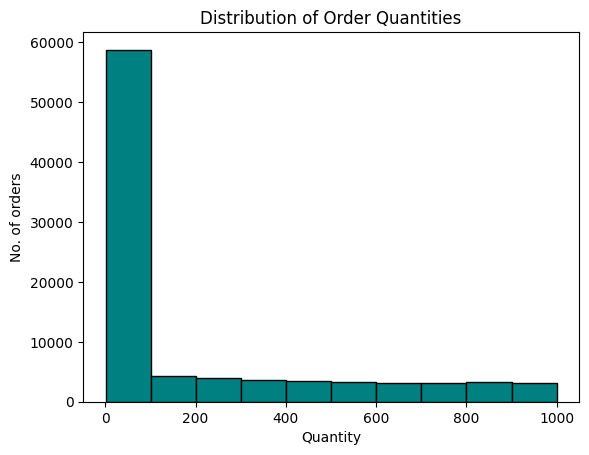

In [7]:
# 1. Distribution of Quantity
plt.hist(df["Quantity"], bins=10, color='teal', edgecolor='black')
plt.title('Distribution of Order Quantities')
plt.xlabel('Quantity')
plt.ylabel('No. of orders')
plt.show()

The above graph shows that this data contains the mixed transactions of normal customers and whole sellers 

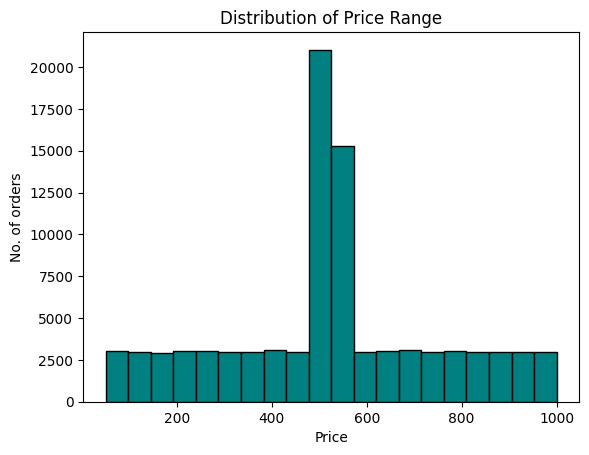

In [8]:
# 2. Distribution of Unit Price
plt.hist(df["Price"], bins=20, color='teal', edgecolor='black')
plt.title('Distribution of Price Range')
plt.xlabel('Price')
plt.ylabel('No. of orders')
plt.show()

This graph shows that the unit price range of 500-600$ has the most transactions.

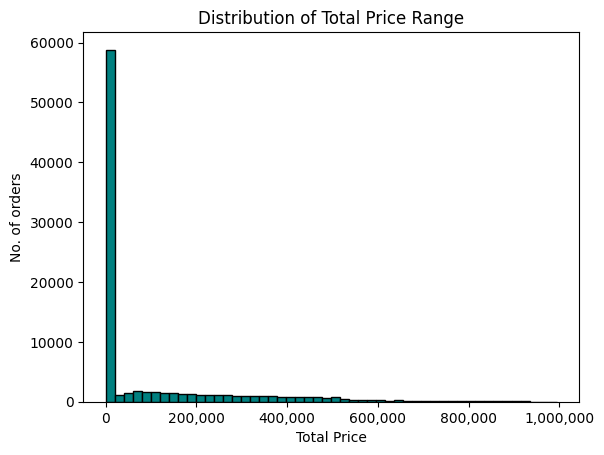

In [9]:
# 3. Distribution of Total Price
plt.hist(df["Total_Amount"], bins=50, color='teal', edgecolor='black')
plt.ticklabel_format(style='plain', axis='x')
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.title('Distribution of Total Price Range')
plt.xlabel('Total Price')
plt.ylabel('No. of orders')
plt.show()

This distrutribution of total price in this graph is eneven, most of the data is in the first bin (say 15,000 range), resulting in a skewed graph, therefore to view the graph clearly, we will separate the bulk orders and normal orders into separate dataframes.

In [10]:
normal_df = df[df["Quantity"] <= 12]
bulk_df = df[df["Quantity"] > 12]

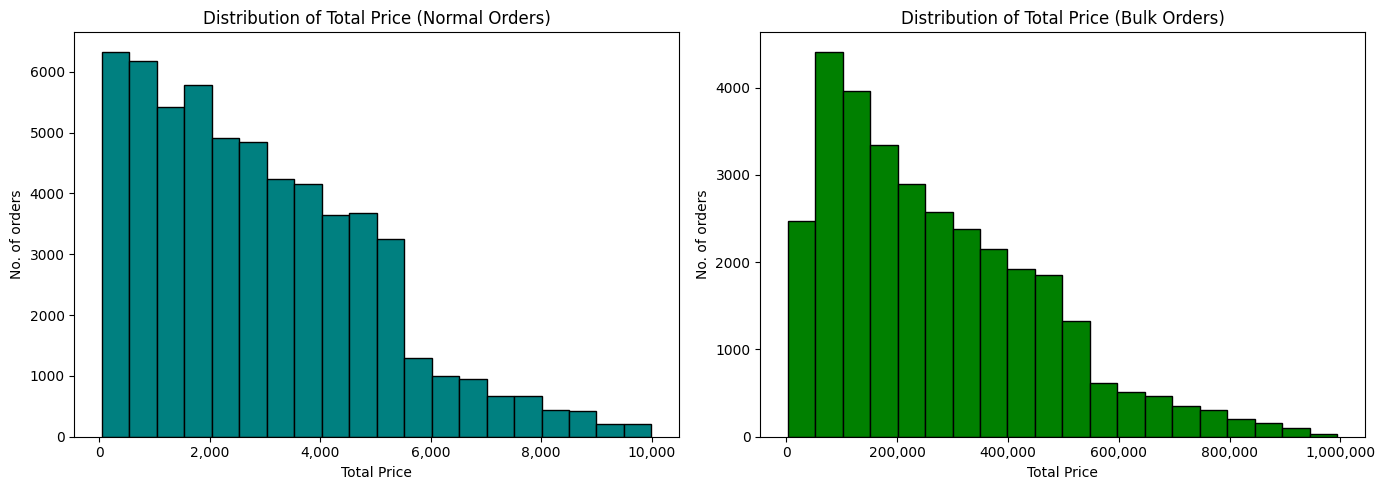

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(normal_df["Total_Amount"], bins=20, color='teal', edgecolor='black')
ax1.ticklabel_format(style='plain', axis='x')
ax1.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax1.set_title('Distribution of Total Price (Normal Orders)')
ax1.set_xlabel('Total Price')
ax1.set_ylabel('No. of orders')

ax2.hist(bulk_df["Total_Amount"], bins=20, color='green', edgecolor='black')
ax2.ticklabel_format(style='plain', axis='x')
ax2.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax2.set_title('Distribution of Total Price (Bulk Orders)')
ax2.set_xlabel('Total Price')
ax2.set_ylabel('No. of orders')

plt.tight_layout()
plt.show()

## Bivariate Analysis

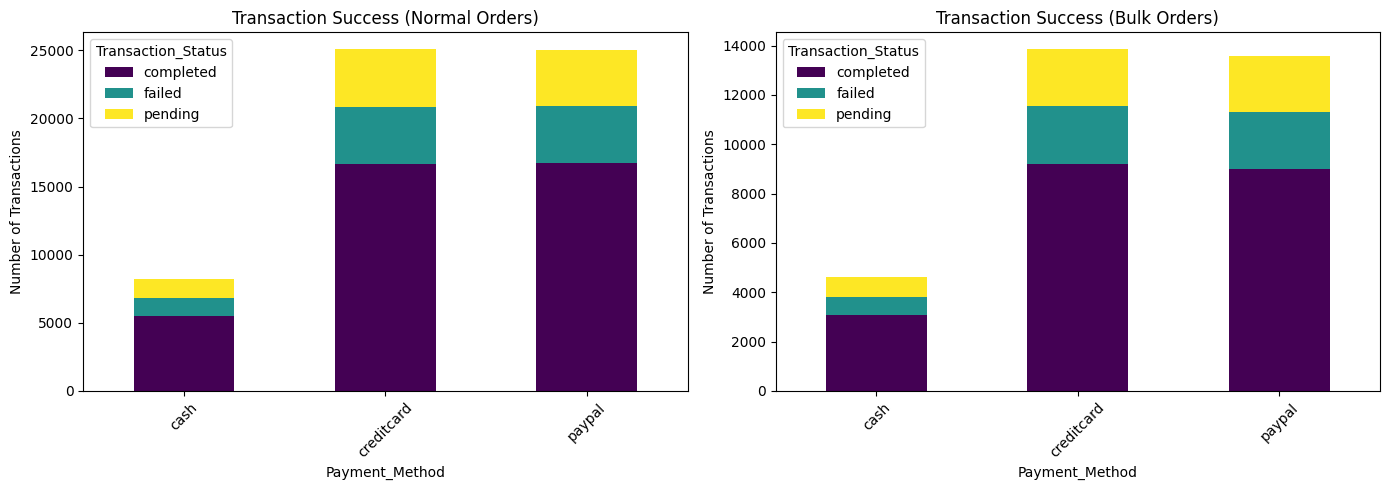

In [12]:
# 1. Payment Method vs. Transaction Status (Stacked Bar)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

status_payment_normal = pd.crosstab(normal_df['Payment_Method'], normal_df['Transaction_Status'])
status_payment_normal.plot(kind='bar', stacked=True, ax=ax1, colormap='viridis')
ax1.set_title('Transaction Success (Normal Orders)')
ax1.set_ylabel('Number of Transactions')
ax1.tick_params(axis='x', rotation=45)

status_payment_bulk = pd.crosstab(bulk_df['Payment_Method'], bulk_df['Transaction_Status'])
status_payment_bulk.plot(kind='bar', stacked=True, ax=ax2, colormap='viridis')
ax2.set_title('Transaction Success (Bulk Orders)')
ax2.set_ylabel('Number of Transactions')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

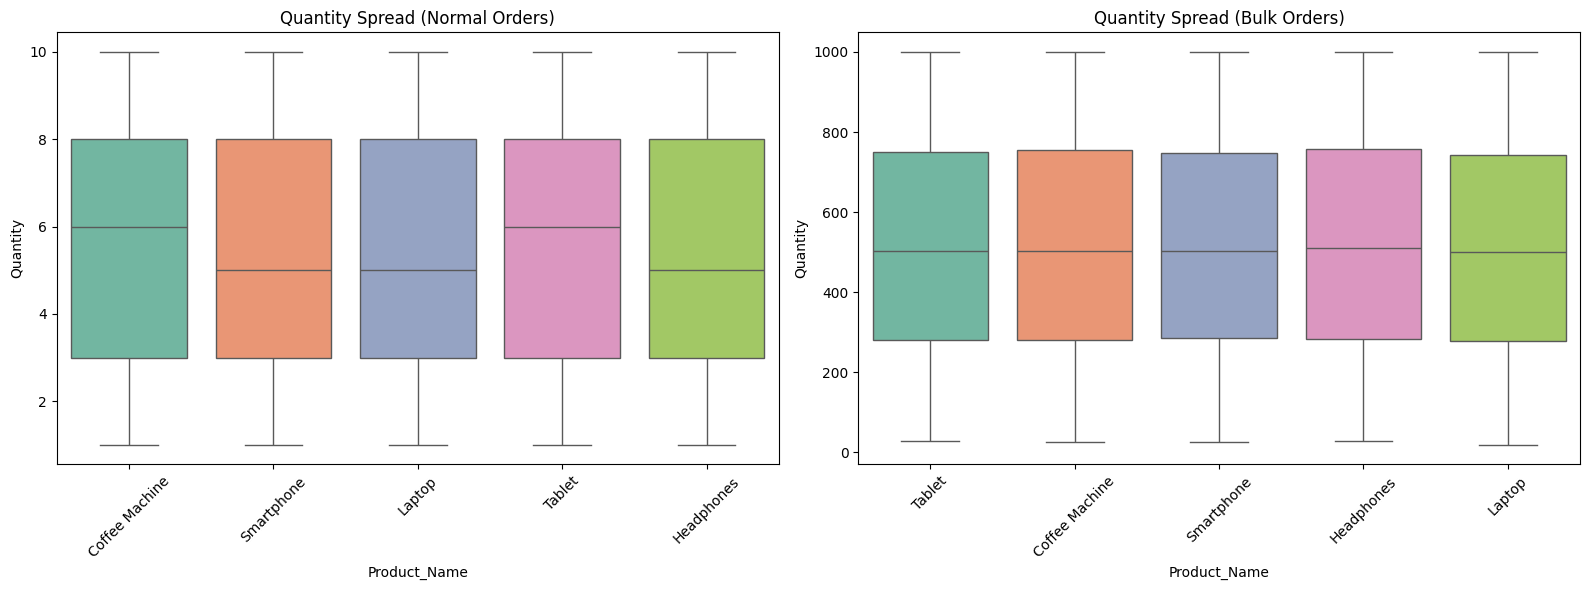

In [13]:
# 2. Product Name vs. Quantity (Boxplot to find Outliers)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=normal_df, x='Product_Name', y='Quantity', palette='Set2', ax=ax1)
ax1.set_title('Quantity Spread (Normal Orders)')
ax1.tick_params(axis='x', rotation=45)

sns.boxplot(data=bulk_df, x='Product_Name', y='Quantity', palette='Set2', ax=ax2)
ax2.set_title('Quantity Spread (Bulk Orders)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

No such outliers found

# Deep Dive: Why do Transactions Fail or Delay?

To understand the root cause of failures and delays, we need to analyze the **Failure Rate** and **Pending Rate** across different segments.

In [14]:
# 1. Feature Engineering: Binary Indicators
df['Is_Failed'] = (df['Transaction_Status'] == 'failed').astype(int)
df['Is_Pending'] = (df['Transaction_Status'] == 'pending').astype(int)
df['Has_Issue'] = (df['Transaction_Status'] != 'completed').astype(int)

print("New features created: Is_Failed, Is_Pending, Has_Issue")

New features created: Is_Failed, Is_Pending, Has_Issue


## 1. Failure Rates by Payment Method
Counts can be misleading if one payment method is used more often. We need to look at percentages.

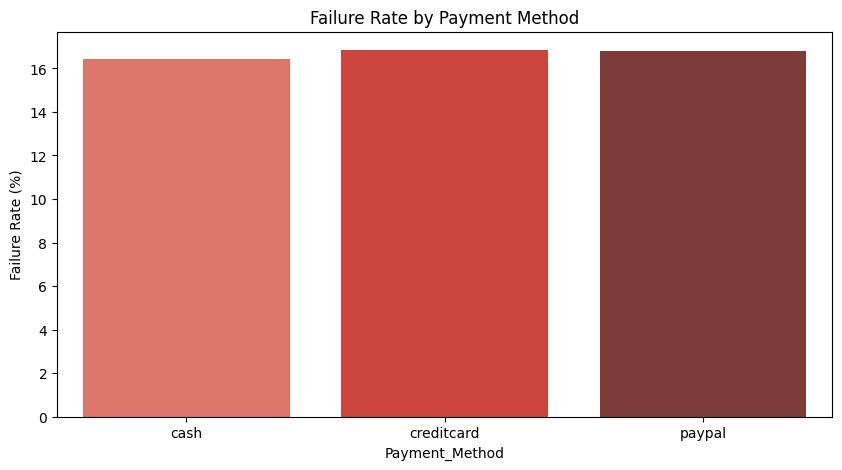

,Payment_Method,Failure_Rate (%),Pending_Rate (%)
0,cash,16.420003,17.043153
1,creditcard,16.851248,16.702212
2,paypal,16.799274,16.532331


In [15]:
payment_issues = df.groupby('Payment_Method').agg({
    'Is_Failed': 'mean',
    'Is_Pending': 'mean'
}).reset_index()

payment_issues['Failure_Rate (%)'] = payment_issues['Is_Failed'] * 100
payment_issues['Pending_Rate (%)'] = payment_issues['Is_Pending'] * 100

plt.figure(figsize=(10, 5))
sns.barplot(data=payment_issues, x='Payment_Method', y='Failure_Rate (%)', palette='Reds_d')
plt.title('Failure Rate by Payment Method')
plt.ylabel('Failure Rate (%)')
plt.show()

display(payment_issues[['Payment_Method', 'Failure_Rate (%)', 'Pending_Rate (%)']])

## 2. Temporal Analysis: Are there 'Bad Days' for Transactions?
Do failure rates spike on weekends or specific days?

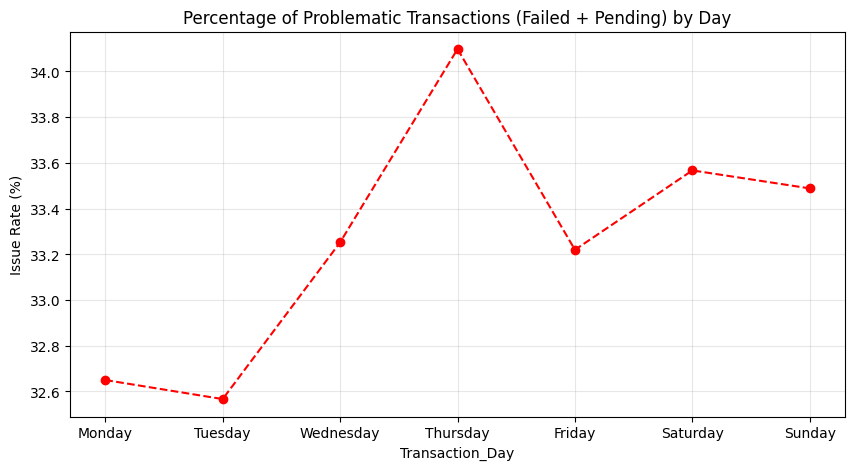

In [16]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_issues = df.groupby('Transaction_Day')['Has_Issue'].mean().reindex(day_order) * 100

plt.figure(figsize=(10, 5))
day_issues.plot(kind='line', marker='o', color='red', linestyle='--')
plt.title('Percentage of Problematic Transactions (Failed + Pending) by Day')
plt.ylabel('Issue Rate (%)')
plt.grid(True, alpha=0.3)
plt.show()

## 3. Transaction Value vs. Success
Do high-value transactions fail more often? (Potential fraud filters or bank limits)

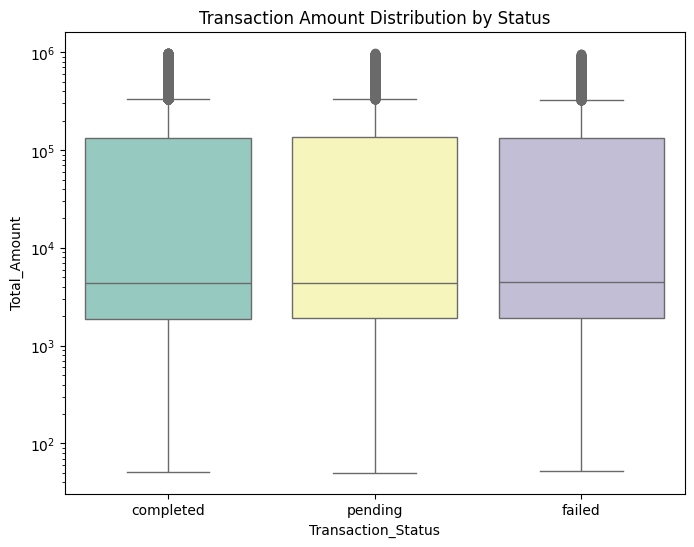

In [17]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Transaction_Status', y='Total_Amount', palette='Set3')
plt.yscale('log') # Using log scale because of bulk orders
plt.title('Transaction Amount Distribution by Status')
plt.show()

## 4. Product-Specific Reliability
Some products might have higher failure rates due to high demand, inventory syncing issues, or higher price points.

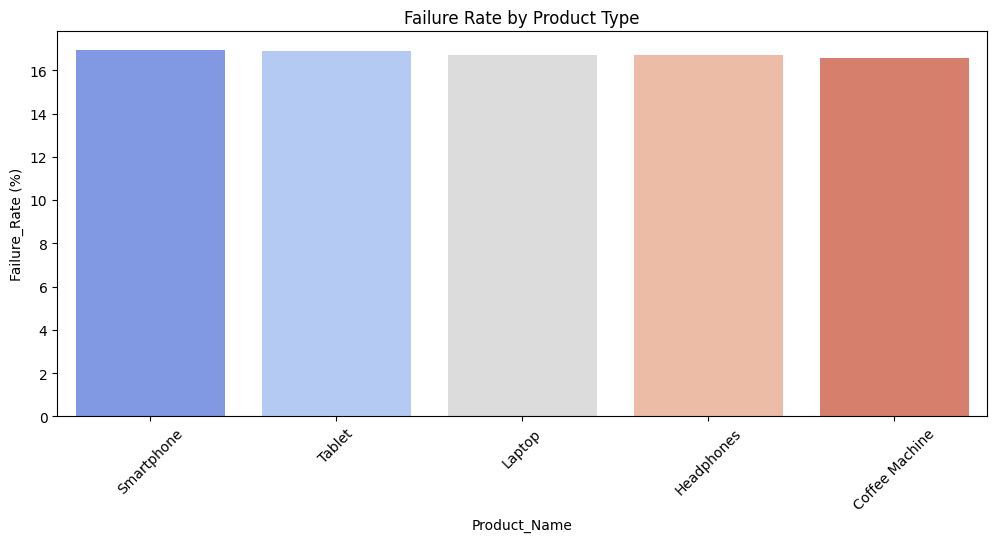

,Failure_Rate (%),Total_Amount
Product_Name,,
Smartphone,16.943174,4387.75950
Tablet,16.894676,4451.84000
Laptop,16.711037,4463.49150
Headphones,16.703687,4443.41949
Coffee Machine,16.583138,4326.56425


In [18]:
product_issues = df.groupby('Product_Name').agg({
    'Is_Failed': 'mean',
    'Total_Amount': 'median'
}).sort_values('Is_Failed', ascending=False)

product_issues['Failure_Rate (%)'] = product_issues['Is_Failed'] * 100

plt.figure(figsize=(12, 5))
sns.barplot(x=product_issues.index, y=product_issues['Failure_Rate (%)'], palette='coolwarm')
plt.title('Failure Rate by Product Type')
plt.xticks(rotation=45)
plt.show()

display(product_issues[['Failure_Rate (%)', 'Total_Amount']])

## 5. Multi-variate Analysis: Correlation Heatmap
Now we look at the statistical relationship between all numerical features and our target `Is_Failed`.

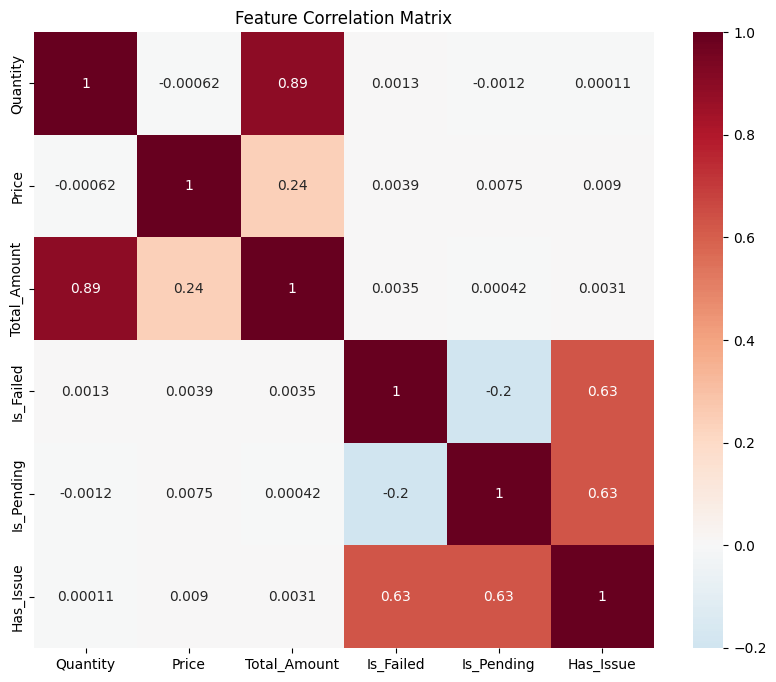

In [19]:
numerical_cols = ['Quantity', 'Price', 'Total_Amount', 'Is_Failed', 'Is_Pending', 'Has_Issue']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

## Final Conclusion & Export

**Key Insights for the Business:**
1. **Primary Drivers**: Check the correlation heatmap for the strongest link to `Is_Failed`.
2. **Risk Segments**: Identify the Payment Method and Product with the highest failure rates.
3. **Customer Loyalty**: Determine if repeat customers face fewer issues (often true due to saved payment info).

**Data Readiness:**
The dataset now has 5 new engineered features: `Total_Amount`, `Is_Failed`, `Is_Pending`, `Has_Issue`, and `Is_Repeat_Customer`.

---

In [20]:
# Export the final engineered dataset for Phase 04 (NLP)
df.to_parquet("engineered_financial_data.parquet", index=False)
print("Success! Dataset saved as 'engineered_financial_data.parquet'. Ready for Phase 04.")

Success! Dataset saved as 'engineered_financial_data.parquet'. Ready for Phase 04.
